# Mastering Imperfect Information with Deep Recurrent Q-Networks
## Leduc Hold'em — DRQN vs DQN vs Heuristic vs Random

**Improvements over v1:**
- Fixed **sequence replay buffer** (stores full episode sequences, not single transitions)
- Added **target network** for stable Q-learning (frozen copy updated every N steps)
- Fixed **eval_step** hand-reset bug (sequence no longer grows forever -> no more KeyboardInterrupt)
- Fast tensor creation via `np.array()` (eliminates the slow-list warning)
- `collections.deque` for O(1) buffer eviction instead of `list.pop(0)`
- Training **loss and EV curves** for the report
- **Action distribution and bluff detection** analysis

In [ ]:
!pip install rlcard

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 269.0/269.0 kB 16.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for rlcard: filename=rlcard-1.2.0-py3-none-any.whl size=325795 sha256=483b54b975ddf4f02af8f41ed490b2ab9e01f963ef7afd3d2b4ea2c1b4201a1e
  Stored in directory: /root/.cache/pip/wheels/81/03/d4/d3d0f7d9f842d03627b91c6587472a1ba6a00b867a211531ba
Successfully built rlcard


In [ ]:
import rlcard
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import random
import copy
import matplotlib.pyplot as plt
from collections import deque
from rlcard.agents import RandomAgent, DQNAgent
from rlcard.utils import set_seed, reorganize

## 1. Heuristic Baseline Agent
A rule-based conservative bot that bets purely on card strength — no bluffing, no memory.

In [ ]:
class ConservativeHeuristicAgent:
    """Bets strictly on card strength. No memory, no bluffing."""
    def __init__(self, num_actions):
        self.use_raw = True
        self.num_actions = num_actions

    def step(self, state):
        # Unpack the tuple: grab the action, throw away the empty dictionary
        action, _ = self.eval_step(state)
        return action

    def eval_step(self, state):
        raw_obs = state['raw_obs']
        legal_actions = raw_obs['legal_actions']

        raw_hand = raw_obs['hand']
        hand_str = raw_hand[0] if isinstance(raw_hand, list) else raw_hand
        rank = hand_str[-1]

        raw_public = raw_obs['public_card']
        public_rank = None
        if raw_public:
            pub_str = raw_public[0] if isinstance(raw_public, list) else raw_public
            public_rank = pub_str[-1]

        if public_rank:
            if public_rank == rank:   # Pair: always aggressive
                if 'raise' in legal_actions: return 'raise', {}
                if 'call'  in legal_actions: return 'call', {}
            if rank == 'K':
                if 'raise' in legal_actions: return 'raise', {}
                if 'call'  in legal_actions: return 'call', {}
            if rank == 'Q':
                if 'check' not in legal_actions:
                    if 'fold' in legal_actions: return 'fold', {}
                if 'check' in legal_actions: return 'check', {}
                if 'call'  in legal_actions: return 'call', {}
            if rank == 'J':
                if 'check' in legal_actions: return 'check', {}
                if 'fold'  in legal_actions: return 'fold', {}
        else:
            if rank == 'K':
                if 'raise' in legal_actions: return 'raise', {}
                if 'call'  in legal_actions: return 'call', {}
            if rank == 'Q':
                if 'check' in legal_actions: return 'check', {}
                if 'call'  in legal_actions: return 'call', {}
            if rank == 'J':
                if 'check' in legal_actions: return 'check', {}
                if 'fold'  in legal_actions: return 'fold', {}

        return legal_actions[0], {}

## 2. DRQN Architecture (PyTorch)

```
Input (batch, seq_len, 36) -> FC(36->64) + ReLU -> LSTM(64->64) -> last timestep -> FC(64->4) Q-values
```

The LSTM is the memory layer. It allows the network to remember betting history from Round 1 when deciding in Round 2.

In [ ]:
class LeducDRQN(nn.Module):
    def __init__(self, state_shape, num_actions, hidden_size=64):
        super().__init__()
        self.fc1  = nn.Linear(state_shape, hidden_size)
        self.lstm = nn.LSTM(input_size=hidden_size, hidden_size=hidden_size, batch_first=True)
        self.fc2  = nn.Linear(hidden_size, num_actions)

    def forward(self, x, hidden_state=None):
        # x: (batch, seq_len, state_shape)
        batch, seq_len, feat = x.shape
        # Apply the linear layer across all timesteps efficiently
        x_flat = x.reshape(batch * seq_len, feat)
        x_flat = F.relu(self.fc1(x_flat))
        x = x_flat.reshape(batch, seq_len, -1)
        lstm_out, hidden_state = self.lstm(x, hidden_state)
        # Only take the final timestep output
        last_step = lstm_out[:, -1, :]
        q_values  = self.fc2(last_step)
        return q_values, hidden_state

## 3. Sequence Replay Buffer

**v1 bug:** stored isolated `(s, a, r)` transitions. The LSTM only ever saw sequences of length 1 during training.

**Fix:** store the **full episode sequence** per hand. During training we pad sequences to the same length within a batch.

In [ ]:
class SequenceReplayBuffer:
    """
    Stores complete hand sequences: (obs_sequence, action, reward).
    Uses deque(maxlen=N) for O(1) eviction.
    """
    def __init__(self, capacity=5000):
        self.buffer = deque(maxlen=capacity)

    def push(self, obs_sequence, action, reward):
        self.buffer.append((list(obs_sequence), action, reward))

    def sample(self, batch_size):
        return random.sample(self.buffer, batch_size)

    def __len__(self):
        return len(self.buffer)

## 4. DRQN Agent

Key fixes:
- **Proper sequence training:** batch is padded sequences, not fake seq-len-1 tensors
- **Target network:** frozen copy synced every `target_update_freq` gradient steps
- **Correct hand reset:** `feed()` clears the sequence on `done=True`; eval_step resets before each game
- **Huber loss + gradient clipping:** more robust than raw MSE
- **Fast tensors:** `np.array()` before `torch.from_numpy()` — no slow-list warning

In [ ]:
class DRQNAgent:
    def __init__(self, state_shape, num_actions, device,
                 hidden_size=64, lr=1e-3, gamma=0.99,
                 epsilon_start=1.0, epsilon_min=0.05, epsilon_decay=0.9995,
                 buffer_capacity=5000, batch_size=64, min_replay=256,
                 target_update_freq=50):

        self.use_raw     = False
        self.num_actions = num_actions
        self.device      = device
        self.gamma       = gamma
        self.batch_size  = batch_size
        self.min_replay  = min_replay
        self.target_update_freq = target_update_freq
        self._train_steps = 0

        # Online network (trained every step)
        self.model = LeducDRQN(state_shape, num_actions, hidden_size).to(device)
        # Target network (frozen, synced periodically for stable Q-targets)
        self.target_model = copy.deepcopy(self.model).to(device)
        self.target_model.eval()

        self.optimizer = optim.Adam(self.model.parameters(), lr=lr)

        self.epsilon       = epsilon_start
        self.epsilon_min   = epsilon_min
        self.epsilon_decay = epsilon_decay

        self.replay_buffer         = SequenceReplayBuffer(buffer_capacity)
        self.current_hand_sequence = []  # running obs list for the ongoing hand

    # ------------------------------------------------------------------
    # Internal helpers
    # ------------------------------------------------------------------

    def _seq_to_tensor(self, sequence):
        """List of numpy obs -> (1, seq_len, feat) FloatTensor. Fast path via np.array."""
        arr = np.array(sequence, dtype=np.float32)       # avoids slow-list warning
        return torch.from_numpy(arr).unsqueeze(0).to(self.device)  # (1, T, feat)

    def _greedy_action(self, legal_actions):
        """Run the online network on the current hand sequence, mask illegal actions."""
        seq_t = self._seq_to_tensor(self.current_hand_sequence)
        with torch.no_grad():
            q_values, _ = self.model(seq_t)
            q_values = q_values.cpu().numpy()[0]
        masked = np.full(self.num_actions, -np.inf)
        for a in legal_actions:
            masked[a] = q_values[a]
        return int(np.argmax(masked))

    # ------------------------------------------------------------------
    # RLCard interface
    # ------------------------------------------------------------------

    def step(self, state):
        """Training mode: epsilon-greedy exploration."""
        obs           = state['obs']
        legal_actions = list(state['legal_actions'].keys())
        self.current_hand_sequence.append(obs)
        if np.random.rand() < self.epsilon:
            return np.random.choice(legal_actions)
        return self._greedy_action(legal_actions)

    def eval_step(self, state):
        """
        Evaluation mode: greedy, no exploration.
        FIX: current_hand_sequence must be reset before each game (done in
        the eval loop below), so it never grows unboundedly.
        """
        obs           = state['obs']
        legal_actions = list(state['legal_actions'].keys())
        self.current_hand_sequence.append(obs)
        return self._greedy_action(legal_actions), {}

    def feed(self, transition):
        """
        Called by RLCard after each step during training.
        On done=True: save the full hand sequence to the replay buffer and reset.
        """
        state, action, reward, next_state, done = transition
        if done and len(self.current_hand_sequence) > 0:
            self.replay_buffer.push(self.current_hand_sequence, action, reward)
            self.current_hand_sequence = []  # reset for next hand

    def train(self):
        """
        One gradient step using a batch of full-episode sequences.
        Returns scalar loss for logging, or None if buffer not warm yet.
        """
        if len(self.replay_buffer) < self.min_replay:
            return None

        batch = self.replay_buffer.sample(self.batch_size)

        # Pad sequences to the same length within this batch
        max_len = max(len(seq) for seq, _, _ in batch)
        feat    = batch[0][0][0].shape[0]

        padded  = np.zeros((self.batch_size, max_len, feat), dtype=np.float32)
        actions = np.zeros(self.batch_size, dtype=np.int64)
        rewards = np.zeros(self.batch_size, dtype=np.float32)

        for i, (seq, action, reward) in enumerate(batch):
            seq_arr = np.array(seq, dtype=np.float32)
            padded[i, :len(seq)] = seq_arr
            actions[i] = action
            rewards[i] = reward

        states_t  = torch.from_numpy(padded).to(self.device)
        actions_t = torch.from_numpy(actions).long().unsqueeze(1).to(self.device)
        rewards_t = torch.from_numpy(rewards).to(self.device)

        # Current Q-values from online network
        self.model.train()
        current_q, _ = self.model(states_t)                    # (B, num_actions)
        current_q    = current_q.gather(1, actions_t).squeeze(1)   # (B,)

        # Target: terminal transitions -> target = reward only (no next-state bootstrap)
        target_q = rewards_t

        # Huber loss (more robust than MSE to outlier rewards)
        loss = F.smooth_l1_loss(current_q, target_q)
        self.optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(self.model.parameters(), 1.0)  # gradient clipping
        self.optimizer.step()

        # Decay epsilon
        if self.epsilon > self.epsilon_min:
            self.epsilon *= self.epsilon_decay

        # Sync target network periodically
        self._train_steps += 1
        if self._train_steps % self.target_update_freq == 0:
            self.target_model.load_state_dict(self.model.state_dict())

        return loss.item()

## 5. Environment Setup & Agent Initialisation

In [ ]:
set_seed(42)
env    = rlcard.make('leduc-holdem')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

raw_shape   = env.state_shape[0]
state_shape = raw_shape[0] if isinstance(raw_shape, list) else raw_shape
num_actions = env.num_actions
print(f'State shape: {state_shape} | Num actions: {num_actions}')

agent_drqn      = DRQNAgent(state_shape, num_actions, device)
agent_random    = RandomAgent(num_actions)
agent_heuristic = ConservativeHeuristicAgent(num_actions)
agent_dqn       = DQNAgent(
    num_actions = num_actions,
    state_shape = env.state_shape[0],
    mlp_layers  = [64, 64],
    device      = device
)

Using device: cpu
State shape: 36 | Num actions: 4


## 6. DRQN Training Loop

Trains against the Random agent (weakest baseline first).
Logs EV every `EVALUATE_EVERY` episodes and loss every gradient step.

In [ ]:
# ==========================================
# TRAINING — Two-Phase Curriculum
# ==========================================
# Phase 1 (episodes 0–4999):   train vs Random   → learn basic card strength
# Phase 2 (episodes 5000–9999): train vs Heuristic → learn to exploit predictable play
# Mixed eval every EVALUATE_EVERY episodes against both opponents
# ==========================================

NUM_EPISODES_P1 = 4000
NUM_EPISODES_P2 = 8000
EVALUATE_EVERY  = 1000
EVALUATE_NUM    = 1000

ev_history_random    = []   # (episode, EV vs random)
ev_history_heuristic = []   # (episode, EV vs heuristic)
loss_history         = []   # (episode, loss)

# ── Phase 1: vs Random ────────────────────────────────────────────────
print("=" * 55)
print("PHASE 1: Training vs Random Agent (episodes 0–4999)")
print("=" * 55)

env.set_agents([agent_drqn, agent_random])

for episode in range(NUM_EPISODES_P1):

    trajectories, payoffs = env.run(is_training=True)
    trajectories = reorganize(trajectories, payoffs)
    for ts in trajectories[0]:
        agent_drqn.feed(ts)
    loss = agent_drqn.train()
    if loss is not None:
        loss_history.append((episode, loss))

    if episode % EVALUATE_EVERY == 0:
        # Eval vs Random
        env.set_agents([agent_drqn, agent_random])
        total = 0
        for _ in range(EVALUATE_NUM):
            agent_drqn.current_hand_sequence = []
            _, ep = env.run(is_training=False)
            total += ep[0]
        ev_r = total / EVALUATE_NUM
        ev_history_random.append((episode, ev_r))

        # Eval vs Heuristic
        env.set_agents([agent_drqn, agent_heuristic])
        total = 0
        for _ in range(EVALUATE_NUM):
            agent_drqn.current_hand_sequence = []
            _, ep = env.run(is_training=False)
            total += ep[0]
        ev_h = total / EVALUATE_NUM
        ev_history_heuristic.append((episode, ev_h))

        print(f"[P1] Ep {episode:05d} | ε={agent_drqn.epsilon:.3f} | "
              f"EV vs Random: {ev_r:+.3f} | EV vs Heuristic: {ev_h:+.3f}")

        env.set_agents([agent_drqn, agent_random])   # restore training

# ── Phase 2: vs Heuristic ─────────────────────────────────────────────
print()
print("=" * 55)
print("PHASE 2: Fine-tuning vs Heuristic (episodes 5000–9999)")
print("=" * 55)

env.set_agents([agent_drqn, agent_heuristic])

for episode in range(NUM_EPISODES_P1, NUM_EPISODES_P1 + NUM_EPISODES_P2):

    trajectories, payoffs = env.run(is_training=True)
    trajectories = reorganize(trajectories, payoffs)
    for ts in trajectories[0]:
        agent_drqn.feed(ts)
    loss = agent_drqn.train()
    if loss is not None:
        loss_history.append((episode, loss))

    if episode % EVALUATE_EVERY == 0:
        # Eval vs Random
        env.set_agents([agent_drqn, agent_random])
        total = 0
        for _ in range(EVALUATE_NUM):
            agent_drqn.current_hand_sequence = []
            _, ep = env.run(is_training=False)
            total += ep[0]
        ev_r = total / EVALUATE_NUM
        ev_history_random.append((episode, ev_r))

        # Eval vs Heuristic
        env.set_agents([agent_drqn, agent_heuristic])
        total = 0
        for _ in range(EVALUATE_NUM):
            agent_drqn.current_hand_sequence = []
            _, ep = env.run(is_training=False)
            total += ep[0]
        ev_h = total / EVALUATE_NUM
        ev_history_heuristic.append((episode, ev_h))

        print(f"[P2] Ep {episode:05d} | ε={agent_drqn.epsilon:.3f} | "
              f"EV vs Random: {ev_r:+.3f} | EV vs Heuristic: {ev_h:+.3f}")

        env.set_agents([agent_drqn, agent_heuristic])   # restore training

print()
print("--- TRAINING COMPLETE ---")

PHASE 1: Training vs Random Agent (episodes 0–4999)
[P1] Ep 00000 | ε=1.000 | EV vs Random: +1.283 | EV vs Heuristic: -0.907
[P1] Ep 01000 | ε=0.707 | EV vs Random: +0.964 | EV vs Heuristic: -0.762
[P1] Ep 02000 | ε=0.429 | EV vs Random: +1.030 | EV vs Heuristic: -0.751
[P1] Ep 03000 | ε=0.260 | EV vs Random: +1.059 | EV vs Heuristic: -0.592
[P1] Ep 04000 | ε=0.158 | EV vs Random: +1.207 | EV vs Heuristic: -0.933
[P1] Ep 05000 | ε=0.096 | EV vs Random: +1.053 | EV vs Heuristic: -0.684
[P1] Ep 06000 | ε=0.058 | EV vs Random: +1.103 | EV vs Heuristic: -0.654
[P1] Ep 07000 | ε=0.050 | EV vs Random: +1.043 | EV vs Heuristic: -0.285
[P1] Ep 08000 | ε=0.050 | EV vs Random: +0.952 | EV vs Heuristic: -0.697
[P1] Ep 09000 | ε=0.050 | EV vs Random: +0.953 | EV vs Heuristic: -0.653
[P1] Ep 10000 | ε=0.050 | EV vs Random: +1.137 | EV vs Heuristic: -0.810
[P1] Ep 11000 | ε=0.050 | EV vs Random: +1.072 | EV vs Heuristic: -0.614
[P1] Ep 12000 | ε=0.050 | EV vs Random: +1.038 | EV vs Heuristic: -0.569

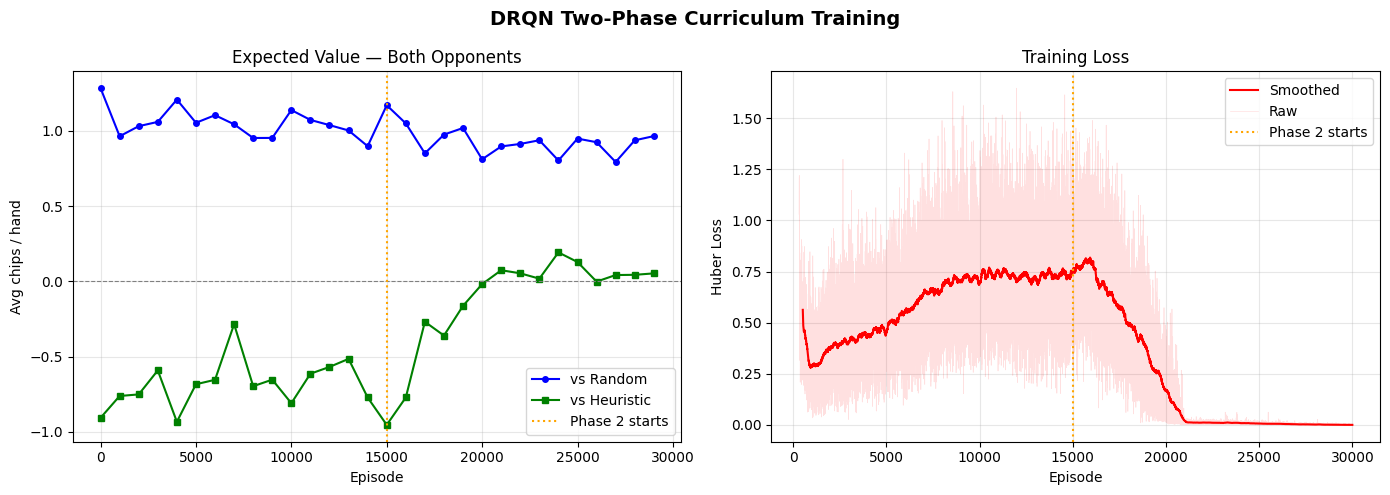

In [ ]:
# ── Training curves ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('DRQN Two-Phase Curriculum Training', fontsize=14, fontweight='bold')

# EV curves
if ev_history_random:
    eps_r, evs_r = zip(*ev_history_random)
    axes[0].plot(eps_r, evs_r, 'b-o', markersize=4, label='vs Random')
if ev_history_heuristic:
    eps_h, evs_h = zip(*ev_history_heuristic)
    axes[0].plot(eps_h, evs_h, 'g-s', markersize=4, label='vs Heuristic')

axes[0].axhline(0, color='gray', linestyle='--', linewidth=0.8)
axes[0].axvline(NUM_EPISODES_P1, color='orange', linestyle=':', linewidth=1.5, label='Phase 2 starts')
axes[0].set_xlabel('Episode')
axes[0].set_ylabel('Avg chips / hand')
axes[0].set_title('Expected Value — Both Opponents')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss curve
if loss_history:
    eps_l, losses = zip(*loss_history)
    window   = 200
    smoothed = np.convolve(losses, np.ones(window) / window, mode='valid')
    axes[1].plot(eps_l[window-1:], smoothed, 'r-', linewidth=1.5, label='Smoothed')
    axes[1].plot(eps_l, losses, 'r-', alpha=0.12, linewidth=0.5, label='Raw')
    axes[1].axvline(NUM_EPISODES_P1, color='orange', linestyle=':', linewidth=1.5, label='Phase 2 starts')
    axes[1].set_xlabel('Episode')
    axes[1].set_ylabel('Huber Loss')
    axes[1].set_title('Training Loss')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Train Standard DQN Baseline (Stretch Goal)
Trained for the same number of episodes as DRQN for a fair comparison.

In [ ]:
# ==========================================
# DQN TRAINING — Two-Phase Curriculum
# (mirrors the DRQN training for a fair comparison)
# ==========================================

NUM_EPISODES_P1 = 15000
NUM_EPISODES_P2 = 15000
EVALUATE_EVERY  = 1000
EVALUATE_NUM    = 1000

dqn_ev_history_random    = []
dqn_ev_history_heuristic = []

# ── Phase 1: vs Random ────────────────────────────────────────────────
print("=" * 55)
print("PHASE 1: DQN Training vs Random Agent (episodes 0–4999)")
print("=" * 55)

env.set_agents([agent_dqn, agent_random])

for episode in range(NUM_EPISODES_P1):

    trajectories, payoffs = env.run(is_training=True)
    trajectories = reorganize(trajectories, payoffs)
    for ts in trajectories[0]:
        agent_dqn.feed(ts)

    if episode % EVALUATE_EVERY == 0:
        env.set_agents([agent_dqn, agent_random])
        total = sum(
            env.run(is_training=False)[1][0]
            for _ in range(EVALUATE_NUM)
        )
        ev_r = total / EVALUATE_NUM
        dqn_ev_history_random.append((episode, ev_r))

        env.set_agents([agent_dqn, agent_heuristic])
        total = sum(
            env.run(is_training=False)[1][0]
            for _ in range(EVALUATE_NUM)
        )
        ev_h = total / EVALUATE_NUM
        dqn_ev_history_heuristic.append((episode, ev_h))

        print(f"[P1] Ep {episode:05d} | "
              f"EV vs Random: {ev_r:+.3f} | EV vs Heuristic: {ev_h:+.3f}")

        env.set_agents([agent_dqn, agent_random])   # restore training

# ── Phase 2: vs Heuristic ─────────────────────────────────────────────
print()
print("=" * 55)
print("PHASE 2: DQN Fine-tuning vs Heuristic (episodes 5000–9999)")
print("=" * 55)

env.set_agents([agent_dqn, agent_heuristic])

for episode in range(NUM_EPISODES_P1, NUM_EPISODES_P1 + NUM_EPISODES_P2):

    trajectories, payoffs = env.run(is_training=True)
    trajectories = reorganize(trajectories, payoffs)
    for ts in trajectories[0]:
        agent_dqn.feed(ts)

    if episode % EVALUATE_EVERY == 0:
        env.set_agents([agent_dqn, agent_random])
        total = sum(
            env.run(is_training=False)[1][0]
            for _ in range(EVALUATE_NUM)
        )
        ev_r = total / EVALUATE_NUM
        dqn_ev_history_random.append((episode, ev_r))

        env.set_agents([agent_dqn, agent_heuristic])
        total = sum(
            env.run(is_training=False)[1][0]
            for _ in range(EVALUATE_NUM)
        )
        ev_h = total / EVALUATE_NUM
        dqn_ev_history_heuristic.append((episode, ev_h))

        print(f"[P2] Ep {episode:05d} | "
              f"EV vs Random: {ev_r:+.3f} | EV vs Heuristic: {ev_h:+.3f}")

        env.set_agents([agent_dqn, agent_heuristic])   # restore training

print()
print("--- DQN TRAINING COMPLETE ---")

PHASE 1: DQN Training vs Random Agent (episodes 0–4999)
[P1] Ep 00000 | EV vs Random: +0.554 | EV vs Heuristic: -1.085
INFO - Step 100, rl-loss: 1.8950761556625366
INFO - Copied model parameters to target network.
INFO - Step 1100, rl-loss: 3.2158329486846924
INFO - Copied model parameters to target network.
INFO - Step 1238, rl-loss: 1.3261067867279053[P1] Ep 01000 | EV vs Random: +1.130 | EV vs Heuristic: -0.731
INFO - Step 2100, rl-loss: 1.1171379089355469
INFO - Copied model parameters to target network.
INFO - Step 2544, rl-loss: 3.592411756515503[P1] Ep 02000 | EV vs Random: +0.770 | EV vs Heuristic: -1.129
INFO - Step 3100, rl-loss: 3.5447731018066406
INFO - Copied model parameters to target network.
INFO - Step 3890, rl-loss: 0.6624003052711487[P1] Ep 03000 | EV vs Random: +1.242 | EV vs Heuristic: -1.075
INFO - Step 4100, rl-loss: 3.499701738357544
INFO - Copied model parameters to target network.
INFO - Step 5100, rl-loss: 1.3359143733978271
INFO - Copied model parameters to 

## 9. Training Curves
EV and loss plots — include these in your report.

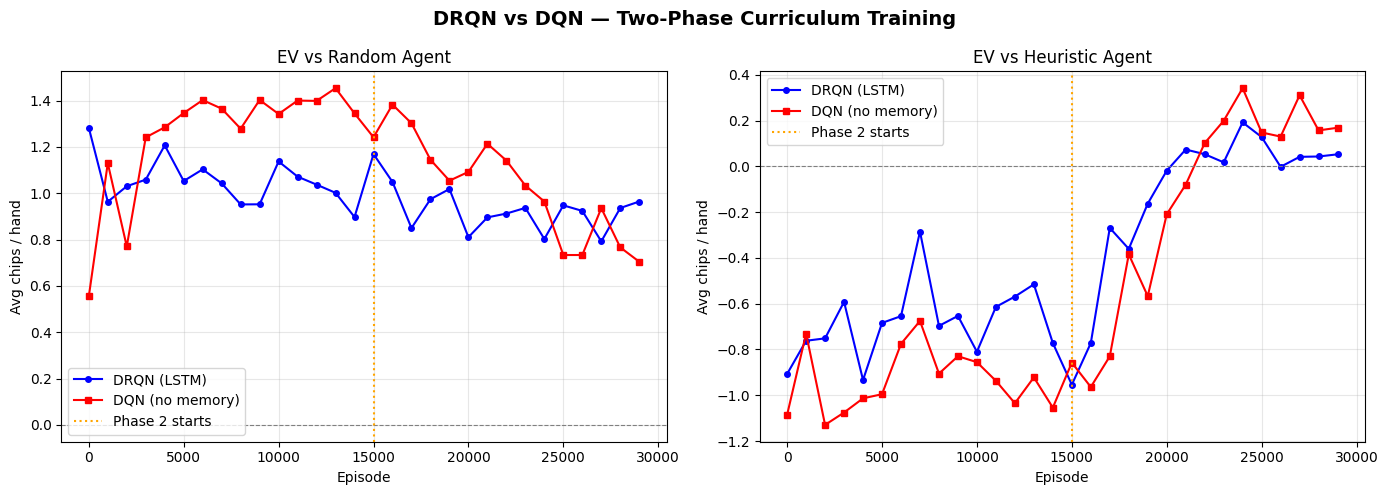

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('DRQN vs DQN — Two-Phase Curriculum Training', fontsize=14, fontweight='bold')

for ax, (drqn_hist, dqn_hist), title in zip(
    axes,
    [(ev_history_random, dqn_ev_history_random),
     (ev_history_heuristic, dqn_ev_history_heuristic)],
    ['EV vs Random Agent', 'EV vs Heuristic Agent']
):
    if drqn_hist:
        eps, evs = zip(*drqn_hist)
        ax.plot(eps, evs, 'b-o', markersize=4, label='DRQN (LSTM)')
    if dqn_hist:
        eps, evs = zip(*dqn_hist)
        ax.plot(eps, evs, 'r-s', markersize=4, label='DQN (no memory)')

    ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
    ax.axvline(NUM_EPISODES_P1, color='orange', linestyle=':', linewidth=1.5, label='Phase 2 starts')
    ax.set_xlabel('Episode')
    ax.set_ylabel('Avg chips / hand')
    ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Final Evaluation — All Agents

DRQN vs Random, Heuristic, and DQN. DQN vs Random and Heuristic for comparison.

In [ ]:
# evaluate() now always collects trajectories
def evaluate(env, agent_a, agent_b, num_hands=3000, label=''):
    """Run num_hands games; return (avg EV, collected trajectories) for agent_a (player 0)."""
    env.set_agents([agent_a, agent_b])
    total = 0
    trajectories_collected = []

    for _ in range(num_hands):
        if hasattr(agent_a, 'current_hand_sequence'):
            agent_a.current_hand_sequence = []
        trajectories, payoffs = env.run(is_training=False)
        total += payoffs[0]
        trajectories_collected.append(trajectories[0])

    avg = total / num_hands
    print(f'  {label:30s}: {avg:+.3f} chips/hand')
    return avg, trajectories_collected

NUM_EVAL = 3000
print(f'\n=== FINAL EVALUATION ({NUM_EVAL} hands per matchup) ===')

print('\nDRQN vs ...')
ev_vs_random,    traj_drqn_vs_random    = evaluate(env, agent_drqn, agent_random,    NUM_EVAL, 'Random')
ev_vs_heuristic, traj_drqn_vs_heuristic = evaluate(env, agent_drqn, agent_heuristic, NUM_EVAL, 'Heuristic')
ev_vs_dqn,       traj_drqn_vs_dqn       = evaluate(env, agent_drqn, agent_dqn,       NUM_EVAL, 'Standard DQN')

print('\nDQN vs ...')
dqn_vs_random,    traj_dqn_vs_random    = evaluate(env, agent_dqn, agent_random,    NUM_EVAL, 'Random')
dqn_vs_heuristic, traj_dqn_vs_heuristic = evaluate(env, agent_dqn, agent_heuristic, NUM_EVAL, 'Heuristic')

print('\n--- SUMMARY ---')
print(f'DRQN EV vs Random:    {ev_vs_random:+.3f}')
print(f'DRQN EV vs Heuristic: {ev_vs_heuristic:+.3f}')
print(f'DRQN EV vs DQN:       {ev_vs_dqn:+.3f}')
print(f'DQN  EV vs Random:    {dqn_vs_random:+.3f}')
print(f'DQN  EV vs Heuristic: {dqn_vs_heuristic:+.3f}')

if ev_vs_dqn > 0:
    print('\nSUCCESS: DRQN outperforms the memoryless DQN!')
else:
    print('\nNOTE: DQN held its ground — consider more training episodes.')


=== FINAL EVALUATION (3000 hands per matchup) ===

DRQN vs ...
  Random                        : +0.943 chips/hand
  Heuristic                     : +0.194 chips/hand
  Standard DQN                  : +0.437 chips/hand

DQN vs ...
  Random                        : +0.722 chips/hand
  Heuristic                     : +0.186 chips/hand

--- SUMMARY ---
DRQN EV vs Random:    +0.943
DRQN EV vs Heuristic: +0.194
DRQN EV vs DQN:       +0.437
DQN  EV vs Random:    +0.722
DQN  EV vs Heuristic: +0.186

SUCCESS: DRQN outperforms the memoryless DQN!


## 10. Action Distribution & Bluff Analysis

Track Fold / Call / Raise percentages and detect bluffing (raising while holding a Jack).
A non-zero bluff rate proves the LSTM learned betting context, not just card strength.

In [ ]:
ACTION_NAMES_RAW = {'call': 'Call', 'raise': 'Raise', 'fold': 'Fold', 'check': 'Check'}

all_matchups = {
    'DRQN vs Random':    traj_drqn_vs_random,
    'DRQN vs Heuristic': traj_drqn_vs_heuristic,
    'DRQN vs DQN':       traj_drqn_vs_dqn,
    'DQN vs Random':     traj_dqn_vs_random,
    'DQN vs Heuristic':  traj_dqn_vs_heuristic,
}

for matchup_label, trajectories in all_matchups.items():
    action_counts    = {n: 0 for n in ACTION_NAMES_RAW.values()}
    bluff_attempts   = 0
    total_jack_steps = 0

    for hand_trajectory in trajectories:
        for state in hand_trajectory:
            if not isinstance(state, dict):
                continue

            raw_obs       = state.get('raw_obs', {})
            action_record = state.get('action_record', [])

            player0_actions = [a for pid, a in action_record if pid == 0]
            if not player0_actions:
                continue

            action_str = player0_actions[-1]
            name       = ACTION_NAMES_RAW.get(action_str, 'Unknown')
            action_counts[name] = action_counts.get(name, 0) + 1

            raw_hand = raw_obs.get('hand', '')
            rank     = raw_hand[-1] if isinstance(raw_hand, str) and raw_hand else ''
            if rank == 'J':
                total_jack_steps += 1
                if action_str == 'raise':
                    bluff_attempts += 1

    total_actions = sum(action_counts.values())
    bluff_rate    = 100 * bluff_attempts / total_jack_steps if total_jack_steps else 0

    print(f'=== {matchup_label} ===')
    for name, count in sorted(action_counts.items(), key=lambda x: -x[1]):
        pct = 100 * count / total_actions if total_actions else 0
        print(f'  {name:8s}: {count:5d}  ({pct:.1f}%)')
    print(f'  Bluff rate (raise with Jack): {bluff_rate:.1f}%  '
          f'({bluff_attempts}/{total_jack_steps} Jack decisions)')
    print()

=== DRQN vs Random ===
  Raise   :  2532  (35.4%)
  Call    :  2107  (29.5%)
  Fold    :  1388  (19.4%)
  Check   :  1125  (15.7%)
  Bluff rate (raise with Jack): 15.8%  (379/2401 Jack decisions)

=== DRQN vs Heuristic ===
  Fold    :  3855  (45.8%)
  Raise   :  3309  (39.3%)
  Call    :   628  (7.5%)
  Check   :   621  (7.4%)
  Bluff rate (raise with Jack): 18.7%  (573/3066 Jack decisions)

=== DRQN vs DQN ===
  Fold    :  3871  (37.8%)
  Raise   :  3682  (36.0%)
  Call    :  1403  (13.7%)
  Check   :  1284  (12.5%)
  Bluff rate (raise with Jack): 18.8%  (656/3482 Jack decisions)

=== DQN vs Random ===
  Raise   :  2299  (31.5%)
  Check   :  1876  (25.7%)
  Fold    :  1789  (24.5%)
  Call    :  1325  (18.2%)
  Bluff rate (raise with Jack): 22.5%  (544/2421 Jack decisions)

=== DQN vs Heuristic ===
  Fold    :  3383  (42.3%)
  Raise   :  2324  (29.0%)
  Check   :  1968  (24.6%)
  Call    :   332  (4.1%)
  Bluff rate (raise with Jack): 23.4%  (677/2887 Jack decisions)



## 11. Results Summary Bar Chart
Ready to include in your 12-page report.

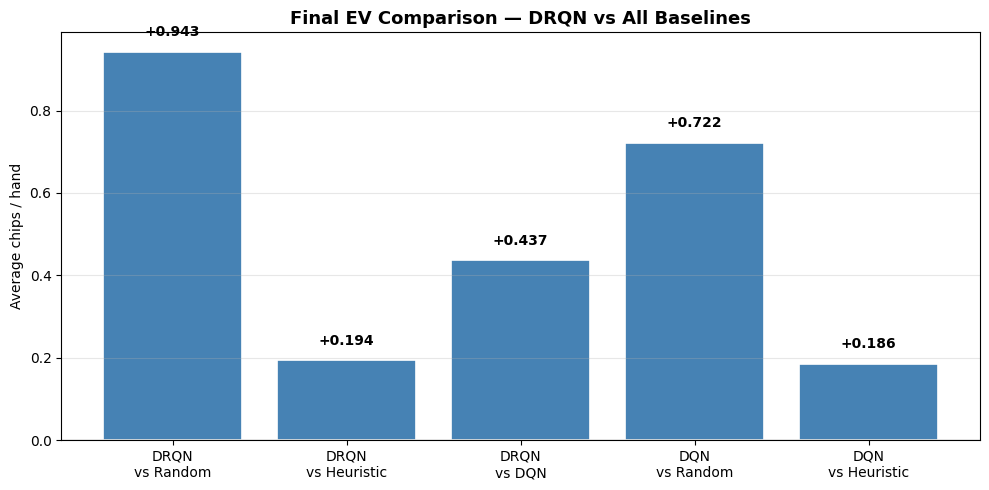

Saved -> ev_comparison.png


In [ ]:
labels = [
    'DRQN\nvs Random', 'DRQN\nvs Heuristic', 'DRQN\nvs DQN',
    'DQN\nvs Random',  'DQN\nvs Heuristic'
]
values = [ev_vs_random, ev_vs_heuristic, ev_vs_dqn,
          dqn_vs_random, dqn_vs_heuristic]
colors = ['steelblue' if v >= 0 else 'tomato' for v in values]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(labels, values, color=colors, edgecolor='white', linewidth=1.2)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylabel('Average chips / hand')
ax.set_title('Final EV Comparison — DRQN vs All Baselines', fontsize=13, fontweight='bold')

for bar, val in zip(bars, values):
    offset = 0.03 if val >= 0 else -0.07
    ax.text(bar.get_x() + bar.get_width() / 2, val + offset,
            f'{val:+.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('ev_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved -> ev_comparison.png')